# MCTS

## It's a planner... It's a learner... It's MCTS!

Monte Carlo Tree Search (MCTS) is a planner that learns the value of actions online by repeatedly simulating future trajectories.
- The planning: It searches forward from the current state by building a lookahead tree to select an action.
- The learning: It incrementally updates the state-action (Q) values within that tree based on the reward signals from its simulated rollouts.
- The planner uses the Q-values to bias its search toward more promising actions, driving new simulations that update the Q-values for those actions.

- Requires an accurate simulator.
- Guaranteed to converge to an optimal action, but only at $\infty$
- Only supports fully observable environments
  - Partially observable version POMCP is out of scope.

## Recap: how does MCTS work?

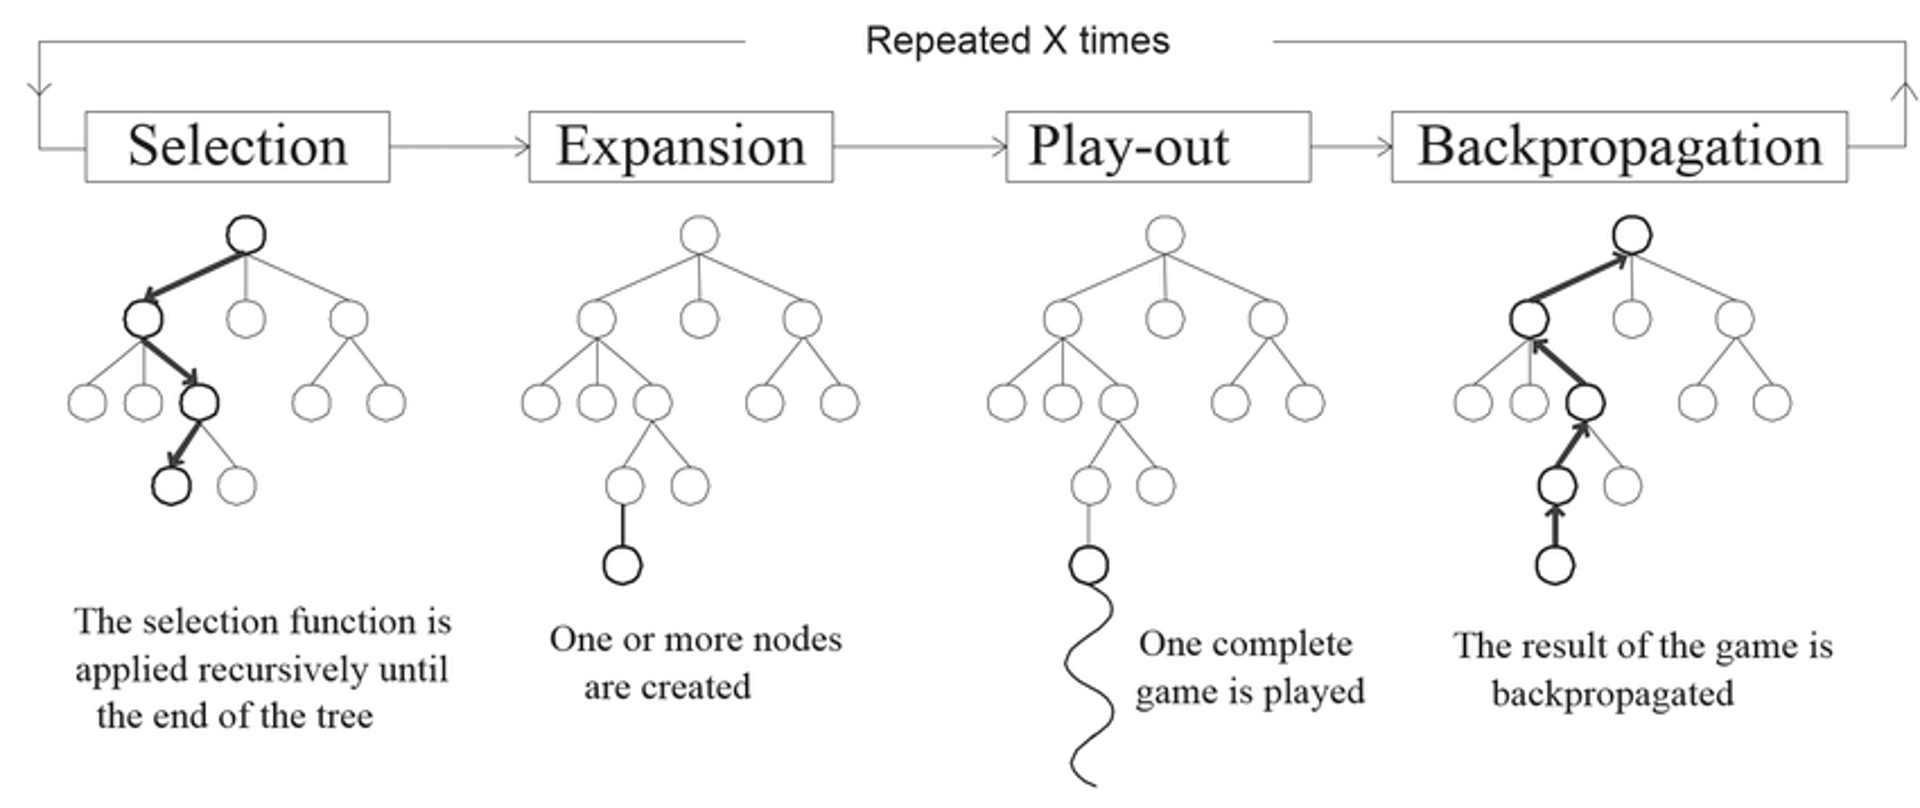

## Exercise: minimal example

Environment: every action has two applicable actions with deterministic outcomes, and rewards are either 1 (win) or 0 (lose).

Let's run through several iterations of UCT MCTS with $c = 1$.

#### Algorithm 1: UCT($s_0$)

**Require:** Initial state $s_0$  
**Ensure:** Best action $a^*$ from $s_0$

1. Initialize search tree with root node $s_0$
2. **for** $i = 1$ to $N$ simulations **do**
3. &nbsp;&nbsp;&nbsp;&nbsp;$s \leftarrow s_0$
4. &nbsp;&nbsp;&nbsp;&nbsp;**Selection:**
5. &nbsp;&nbsp;&nbsp;&nbsp;**while** $s$ fully expanded and not terminal **do**
6. &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Select action $a$ using UCT:
7. &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;$a = \arg\max_a \left( Q(s,a) + c \sqrt{\frac{\ln N(s)}{N(s,a)}} \right)$
8. &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;$s \leftarrow$ next state
9. &nbsp;&nbsp;&nbsp;&nbsp;**end while**
10. &nbsp;&nbsp;&nbsp;&nbsp;**Expansion:** Add a new child node for $s$
11. &nbsp;&nbsp;&nbsp;&nbsp;**Simulation:** Roll out a default policy to terminal state
12. &nbsp;&nbsp;&nbsp;&nbsp;**Backpropagation:** Update $Q$ and visit counts along the path
13. **end for**
14. **return** $a^* = \arg\max_a Q(s_0,a)$

## Solving MCTS

- MCTS is popular and well-documented.
- Countless variants and implementations exist online.

BUT
- Implementations are bespoke.
    - Different variants match different needs.
    - Simulator interfaces vary greatly.
- Often requires great effort to align with your use-case.
- In many cases, the path of least resistance is re-implementation.
  - A testament to the simplicity of this algorithm

Luckily for us, someone has already implemented [gymcts](https://github.com/Alexander-Nasuta/gymcts), a Gymnasium-compatible implementation of MCTS that works well and is surprisingly well-maintained.
- Implementation is the same as our runthrough example.

## Discrete Environment (FrozenLake)

[FrozenLake](https://gymnasium.farama.org/environments/toy_text/frozen_lake/) is a grid navigation environment with traps. Th objective is to navigate from a start position to a goal position without falling through the ice in compromised cells.

In [ ]:
import gymnasium as gym
from PIL import Image

env = gym.make("FrozenLake-v1", is_slippery=False, render_mode="rgb_array")
env.reset()
frame = env.render()
Image.fromarray(frame)

**Action space**: up, down, left, right

In [ ]:
env.action_space

**Observation space**: cell position, calculated as `cur_row * n_cols + cur_col`

In [ ]:
env.observation_space

_Question_: What did we call this kind of problem?

## Using gymcts

### Setup

Our first requirement is a simulator. Since everyting is simulated anyway, let's create another copy of the environment.

In [ ]:
sim = gym.make("FrozenLake-v1", is_slippery=False, render_mode=None)
sim.reset();

Gymnasium environments do not support backtracking natively. gymcts provides a solution: **make the environmnet clonable.**

In [ ]:
from gymcts.gymcts_deepcopy_wrapper import DeepCopyMCTSGymEnvWrapper

sim = DeepCopyMCTSGymEnvWrapper(sim)

The MCTS algorithm is wrapped within an agent class.

In [ ]:
from gymcts.gymcts_agent import GymctsAgent

agent = GymctsAgent(
    env=sim,                                  # the only required argument: the simulator
    clear_mcts_tree_after_step=False,         # reuse information from previous steps
    render_tree_after_step=True,              # visualize the search (for debugging)
    number_of_simulations_per_step=50,        # resource bound per step
    exclude_unvisited_nodes_from_render=True  # remove redundant prints
)

### Planning

gymcts agents implement the `solve` method, which internally runs MCTS iterations while advancing the simulator with committed actions until a terminal state is reached.

We can visualize the process by rendering the search tree at each step.

In [ ]:
actions = agent.solve()

### Execution

So we found a sequence of actions (a plan).

In [ ]:
print(actions)

Let's execute it to verify correctness.

In [ ]:
env.reset()
frames = [env.render()]
for a in actions:
    obs, rew, term, trun, info = env.step(a)
    frames.append(env.render())
print("Execution completed", "successfully" if rew else "unsuccessfully")

In [ ]:
import mediapy as media

media.show_video(frames, fps=3)

## Continuous State Space (CartPole)

In [CartPole](https://gymnasium.farama.org/environments/classic_control/cart_pole/), the agent must balance a pole on a moving cart, receiving a positive reward for every step that the pole didn't fall and the cart stayed its boundaries.

In [ ]:
import gymnasium as gym
from PIL import Image

env = gym.make("CartPole-v1", render_mode="rgb_array")
env.reset()
frame = env.render()
Image.fromarray(frame)

**Action space**: apply force to the left / right

In [ ]:
env.action_space

**Observation space**: cart position, cart velocity, pole angle, pole angular velocity

In [ ]:
env.observation_space

Classical planning assumes a finite state space, and thus cannot help us here.

### Solve with MCTS

The solution here is identical to FrozenLake.
- **Note**: initial states are random, so the environment and the simulator must be reset using the same seed to ensure they start from the same state.

In [ ]:
# disable gymcts logging
from gymcts.logger import log
log.disabled = True

# set random seed for identical initial state in simulator and environment
# change the seed to vary results
import random
seed = random.randint(0, 200)

# initialize CartPole simulator (identical to FrozenLake)
sim = gym.make("CartPole-v1", render_mode=None)
sim.reset(seed=seed)
sim = DeepCopyMCTSGymEnvWrapper(sim)
agent = GymctsAgent(
    env=sim,
    clear_mcts_tree_after_step=False,
    number_of_simulations_per_step=50,
)

# perform MCTS iterations (steps internally)
actions = agent.solve()

# execute
env.reset(seed=seed)
frames = [env.render()]
acc_rew = 0
for a in actions:
    obs, rew, term, trun, info = env.step(a)
    frames.append(env.render())
    acc_rew += rew

print("Completed with reward:", acc_rew)

In [ ]:
media.show_video(frames, fps=30)

## Sparse Rewards (LunarLander)

Cartpole was easy because it we have strong indication of when we are on the right track. What if rewards didn't come at every step?

In [LunarLander](https://gymnasium.farama.org/environments/box2d/lunar_lander/), the goal is to land a spacecraft on the moon within a bounded "landing pad", with bonuses/penalties for landing speed, fuel use, upright orientation, and other factors.

**Key property**: reward is mostly negative until landing.

In [ ]:
env = gym.make("LunarLander-v3", render_mode='rgb_array')
env.reset()
frame = env.render()
Image.fromarray(frame)

**Observation space**: x,y coordinates and linear velocity, angle and angular velocity, and an indicator if each leg is on the ground.

In [ ]:
env.observation_space

**Action space**: fire main thruster, fire left thruster, fire right thurster, do nothing

In [ ]:
env.action_space

### Let's try the same tactic

In [ ]:
from utils.lunar_lander_mcts_wrapper import LunarLanderMCTSWrapper

seed = 42
random.seed(seed)  # make MCTS deterministic as well

sim = gym.make("LunarLander-v3", enable_wind=False, render_mode=None)
sim = LunarLanderMCTSWrapper(sim)
sim.reset(seed=seed)
agent = GymctsAgent(
    env=sim,
    clear_mcts_tree_after_step=False,
    number_of_simulations_per_step=50,
)

actions = agent.solve()

env.reset(seed=seed)
frames = [env.render()]
acc_rew = 0
for a in actions:
    obs, rew, term, trun, info = env.step(a)
    frames.append(env.render())
    acc_rew += rew

print("Completed with reward:", acc_rew)
media.show_video(frames, fps=30)

### More resources

The previous run was not so great. Let's try running more simulations per step

In [ ]:
seed = 42
random.seed(seed)  # make MCTS deterministic as well

sim = gym.make("LunarLander-v3", render_mode=None)
sim = LunarLanderMCTSWrapper(sim)
sim.reset(seed=seed)
agent = GymctsAgent(
    env=sim,
    clear_mcts_tree_after_step=False,
    number_of_simulations_per_step=100,
)

actions = agent.solve()

env.reset(seed=seed)
frames = [env.render()]
acc_rew = 0
for a in actions:
    obs, rew, term, trun, info = env.step(a)
    frames.append(env.render())
    acc_rew += rew

print("Completed with reward:", acc_rew)
media.show_video(frames, fps=30)

Somehow it's worse!

_Question_: How can this be?

_Question_: What else can we do to tune our algorithm?

## The Exploration Constant $c$

In the UCT variant of MCTS, we select which nodes to explore by their upper confidence bound (UCB) score, computed:
$$Q(s,a) + c \sqrt{\frac{\ln N(s)}{N(s,a)}}$$
The value $c$ controls the importance of the number of visits (exploration) vs the already acquired Q value (exploitation).
- A higher $c$ favors less visited state-action pairs.
- A lower $c$ favors state-action pairs with promising return.

### LunarLander with tuned $c$

The spacecraft is already landing fairly close to the target pad. Then it is likely seeing better landing positions in its tree, but choosing to explore more. Let's tighten up exploration by lowering $c$.

By default, gymcts sets $c = \frac{1}{\sqrt{2}} \approx 0.707$, which minimizes regret for environments with rewards in `[-1,1]`. This is not the case for LunarLander. To set $c$, update the value of the class variable `GymctsNode.ubc_c`.

In [ ]:
from gymcts.gymcts_node import GymctsNode
GymctsNode.ubc_c = 0.3

seed = 42
random.seed(seed)  # make MCTS deterministic as well

sim = gym.make("LunarLander-v3", render_mode=None)
sim = LunarLanderMCTSWrapper(sim)
sim.reset(seed=seed)
agent = GymctsAgent(
    env=sim,
    clear_mcts_tree_after_step=False,
    number_of_simulations_per_step=50,
)

actions = agent.solve()

env.reset(seed=seed)
frames = [env.render()]
acc_rew = 0
for a in actions:
    obs, rew, term, trun, info = env.step(a)
    frames.append(env.render())
    acc_rew += rew

print("Completed with reward:", acc_rew)
media.show_video(frames, fps=30)

## Stochastic Action Outcomes (Back to FrozenLake)

The environments tested so far were fully deterministic. What happens when actions have probabilistic outcomes?

Going back to the FrozenLake environment, we can specify that the ice may be slippery, causing the agent to move unpredictably.

In [ ]:
from IPython.display import display

env = gym.make("FrozenLake-v1", is_slippery=True, success_rate=0.8, render_mode="rgb_array")
env.reset()
display(Image.fromarray(env.render()))
env.step(1)  # move down
print('move down')
display(Image.fromarray(env.render()))

_Question__: Can MCTS handle this?

### Solve as usual

In [ ]:
seed = 42
random.seed(seed)

sim = gym.make("FrozenLake-v1", is_slippery=True, success_rate=0.8, render_mode=None)
sim.reset()
sim = DeepCopyMCTSGymEnvWrapper(sim)
agent = GymctsAgent(
    env=sim,
    clear_mcts_tree_after_step=False,
    render_tree_after_step=False,
    number_of_simulations_per_step=50,
    exclude_unvisited_nodes_from_render=True
)

actions = agent.solve()

env.reset()
frames = [env.render()]
for a in actions:
    obs, rew, term, trun, info = env.step(a)
    frames.append(env.render())

media.show_video(frames, fps=3)

_Question_: What is wrong with our current approach?

## Online Planning with MCTS

We cannot hope to do the same kind of offline planning we have done so far.
- When the simulator chooses an action, it commits **within the simulator**.
- The returned action sequence is chosen accoring to the outcomes in the simulator.
- When running these actions in the real environment, action oucomes may be different

We need to be adaptable. We need to plan **online**.

### Attempt 2: online planning

We need a gymcts agent that plans from the current state after a step in the **real environment**.

In [ ]:
def get_mcts_agent_for_current_env_state(obs):
    sim = gym.make("FrozenLake-v1", is_slippery=True, success_rate=0.8, render_mode=None)
    sim.reset()
    sim.unwrapped.s = int(obs)
    sim = DeepCopyMCTSGymEnvWrapper(sim)
    agent = GymctsAgent(env=sim)
    return agent

gymcts agents implement the `perform_mcts_step` which enables us to run a one step at a time.

In [ ]:
from IPython.display import clear_output

seed = 42
random.seed(seed)

obs, info = env.reset()
term = trun = False
frames = [env.render()]
i = 0
while not (term or trun):
    agent = get_mcts_agent_for_current_env_state(obs)
    
    a, _ = agent.perform_mcts_step(num_simulations=1000)
    obs, rew, term, trun, info = env.step(a)
    i += 1
    clear_output(wait=True)
    print('steps taken:', i)
    frames.append(env.render())

print("Execution completed", "successfully" if rew else "unsuccessfully")
media.show_video(frames, fps=3)

Even with 1,000 steps it's still failing. What's going on?

### Evaluate many trials

Maybe we were just unlucky. Let's try to run with different seeds and see how well our agent performs.

In [ ]:
from tqdm.auto import tqdm

def run_slippery_episode(seed, num_simulations=1_000):
    random.seed(seed)  # set constant MCTS agent
    env = gym.make("FrozenLake-v1", is_slippery=True, success_rate=0.8, render_mode=None)
    obs, info = env.reset(seed=seed)

    term = trun = False
    successes = 0
    while not (term or trun):
        agent = get_mcts_agent_for_current_env_state(obs)
        a, _ = agent.perform_mcts_step(num_simulations=num_simulations)

        obs, rew, term, trun, info = env.step(a)
    print("Execution completed", "successfully" if rew else "unsuccessfully")
    successes += rew

    return successes


n = 10
wins = sum(run_slippery_episode(seed=i) for i in tqdm(range(n)))
print(f"success rate: {(wins / n) * 100}%")

Still very bad. Why?

## Chance Nodes

The action outcomes are stochastic, but we have been committing to a single outcome for each state-action pair.

![ao-graph](images/AO-GRAPH.png)

Fortuneately, there are extensions to MCTS that support **chance nodes**, e.g., progressive widening

Unfortunately, gymcts does not support this.

Take our AI and Robotics (AIR) course to implement MCTS with double progressive widening from scratch, and learn to handle continuous actions with stochastic outcomes in continuous state spaces.

## Conclusion

MCTS is a powerful and versatile algorithm.
- It provable converges to the optimal action.
- It has many variants for different requirements.
- It will return the best solution it finds under the budget it is given.
- It makes online/adaptable decisions.

However,
- It requires an accurate simulator.
- Can get stuck in a misleading branch.
- Some problems may require vast amounts of resources to solve.
- Exploration constant requires tuning.